# final8 — 완전관측 확장모델

36개월 완전관측 데이터 + 기존 파생변수 + 외부데이터 기반 확장모델입니다. 기존 파생변수/외부데이터 생성 구조는 유지하고, **거래건수 계열과 라벨 후보(y_old/y_v2/y_v3 및 파생 zero_cat)는 모델 feature에서 제거**합니다.

## STEP 0. 라이브러리

In [22]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
)

try:
    from lightgbm import LGBMClassifier
except ImportError as e:
    raise ImportError("lightgbm이 설치되어 있어야 합니다. `pip install lightgbm` 후 다시 실행하세요.") from e

matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # Mac: 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

EPS = 1e-6
EPS2 = 1e-9
RANDOM_STATE = 42
DATA_PATH = '36.csv'
NOTEBOOK_NAME = 'final8'

print(f'NOTEBOOK_NAME = {NOTEBOOK_NAME}')

NOTEBOOK_NAME = final8


## STEP 1. 데이터 로드 + 정렬

In [23]:
import os
# 36개월 완전관측 법인만 (법인데이터.csv)
df = pd.read_csv('iM_edu.csv')
_tm = df['기준년월'].nunique()
_cnt = df.groupby('법인ID').size()
_full = set(_cnt[_cnt == _tm].index)
df = df[df['법인ID'].isin(_full)].copy()
df = df.sort_values(['법인ID', '기준년월']).reset_index(drop=True)
print('완전관측 로드:', df.shape, '| 법인', df['법인ID'].nunique())

완전관측 로드: (121392, 70) | 법인 3372


## STEP 2. 전처리 (수치화 + 결측 처리만)

In [24]:
# ── 2-1. 구간 문자열(좌수/거래건수) → 수치 ──
def parse_count_str(s):
    if pd.isna(s) or str(s) in ['', '-']: return 0
    s = str(s)
    e = re.match(r'^(\d+)[개건]$', s)
    if e: return int(e.group(1))
    b = re.match(r'^(\d+)[개건]초과\s*(\d+)[개건]이하$', s)
    if b: return int(b.group(1)) + 1
    o = re.match(r'^(\d+)[개건]\s*초과$', s)
    if o: return int(o.group(1)) + 1
    return 0
for c in [col for col in df.columns if '좌수' in col or '거래건수' in col or '개수' in col]:
    df[c + '_num'] = df[c].apply(parse_count_str)

# ── 2-2. 결측치 처리 ──
df['지역_결측_여부'] = df['사업장_시도'].isna().astype(int)
df['사업장_시도']   = df['사업장_시도'].fillna('Unknown')
df['사업장_시군구'] = df['사업장_시군구'].fillna('Unknown')
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(0)
print(f"전처리 완료 | 잔여 결측: {df.isnull().sum().sum()}")


전처리 완료 | 잔여 결측: 0


## STEP 3. 타겟 변수(y) 생성 — 논문 정의 (기존과 동일)

베이스라인 비교를 위해 타겟은 그대로 유지한다.
거래빈도 변화율 ≤ -30% **또는** 거래 규칙성(CV) > 평균 → 부분 이탈(1).


In [25]:
# ============================================================
# STEP 3. 타겟 변수 생성 + 1개월 SHIFT 타깃 생성
# - 기존 y_current: 해당 월 거래활동성 약화 여부
# - y_next1: 다음 월 거래활동성 약화 여부
# - 모델 학습용 y는 y_next1로 덮어씀
# ============================================================

# 논문 Frequency 지표 / 거래활동성 약화 proxy 라벨 생성 재료
freq_num_cols = [
    '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num',
    '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num'
]

missing_freq_cols = [c for c in freq_num_cols if c not in df.columns]
if missing_freq_cols:
    raise ValueError(f'거래건수 수치화 컬럼이 없습니다: {missing_freq_cols}')

df = df.sort_values(['법인ID', '기준년월']).copy().reset_index(drop=True)
df['총거래건수'] = df[freq_num_cols].sum(axis=1)

# 조건1: 거래빈도 이동 구간 변화율
# 주의: 기존 코드와 동일하게 현재 row 직전 구간을 사용한다.
# 즉 M_freq_t는 t월 row에서 과거 6개월 흐름을 요약한 값이다.
def compute_rolling_change(series, past=3, recent=3):
    n = len(series)
    M = np.full(n, np.nan)
    for i in range(past + recent, n):
        ps = series.iloc[i-past-recent : i-recent].sum()   # 이전 3개월
        rs = series.iloc[i-recent : i].sum()               # 최근 3개월
        M[i] = (rs - ps) / (ps + EPS)
    return M

df['M_freq'] = df.groupby('법인ID')['총거래건수'].transform(
    lambda x: compute_rolling_change(x.reset_index(drop=True))
)

# 조건2: 거래 규칙성 / 변동계수
def rolling_cv(series, window=6):
    m = series.rolling(window, min_periods=3).mean()
    sd = series.rolling(window, min_periods=3).std()
    return sd / (m + EPS)

df['freq_CV'] = df.groupby('법인ID')['총거래건수'].transform(
    lambda x: rolling_cv(x.reset_index(drop=True)).values
)

# warm-up 행은 y_current 계산 불가
# y_current = 해당 월 기준 거래활동성 약화 여부
df['y_available'] = df['M_freq'].notna() & df['freq_CV'].notna()
CV_BASELINE = df.loc[df['y_available'], 'freq_CV'].mean()

df['y_current'] = np.nan
df.loc[df['y_available'], 'y_current'] = (
    (df.loc[df['y_available'], 'M_freq'] <= -0.30) |
    (df.loc[df['y_available'], 'freq_CV'] > CV_BASELINE)
).astype(int)

# ------------------------------------------------------------
# 1개월 선행 타깃 생성
# X_t -> y_next1 = y_current_{t+1}
# ------------------------------------------------------------
df['y_next1'] = df.groupby('법인ID')['y_current'].shift(-1)
df['target_기준년월'] = df.groupby('법인ID')['기준년월'].shift(-1)

# 모델 학습용 행:
# - 현재월 피처가 안정적으로 계산 가능한 행(y_available=True)
# - 다음월 y가 존재하는 행(y_next1 notna)
model_mask = df['y_available'] & df['y_next1'].notna()
df_model = df.loc[model_mask].copy().reset_index(drop=True)

# 기존 downstream 코드와 호환되도록 y 컬럼명을 유지하되, 내용은 y_next1로 교체
# 즉 이후 모든 모델의 target_col='y'는 실제로 다음월 거래활동성 약화 여부를 의미한다.
df_model['y'] = df_model['y_next1'].astype(int)
df_model['y_current'] = df_model['y_current'].astype(int)

print('=' * 80)
print('Y 1개월 SHIFT 타깃 생성 완료')
print('=' * 80)
print('전체 df shape:', df.shape)
print('모델링 df_model shape:', df_model.shape)
print('warm-up 행 수:', int((~df['y_available']).sum()))
print('다음월 y 없음으로 제외된 행 수:', int((df['y_available'] & df['y_next1'].isna()).sum()))
print('모델 구조: X_t -> y_next1 = y_{t+1}')
print('X 기준월 범위:', df_model['기준년월'].min(), '~', df_model['기준년월'].max())
print('Target 기준월 범위:', df_model['target_기준년월'].min(), '~', df_model['target_기준년월'].max())

print('\n[y_next1 분포: 모델 학습 target y]')
print(df_model['y'].value_counts())
print(df_model['y'].value_counts(normalize=True))

print('\n[샘플: X 기준월 -> target 기준월]')
display(df_model[['법인ID', '기준년월', 'target_기준년월', 'y_current', 'y_next1', 'y']].head(10))


Y 1개월 SHIFT 타깃 생성 완료
전체 df shape: (121392, 107)
모델링 df_model shape: (97788, 108)
warm-up 행 수: 20232
다음월 y 없음으로 제외된 행 수: 3372
모델 구조: X_t -> y_next1 = y_{t+1}
X 기준월 범위: 202307 ~ 202511
Target 기준월 범위: 202308.0 ~ 202512.0

[y_next1 분포: 모델 학습 target y]
y
0    58131
1    39657
Name: count, dtype: int64
y
0    0.594459
1    0.405541
Name: proportion, dtype: float64

[샘플: X 기준월 -> target 기준월]


,법인ID,기준년월,target_기준년월,y_current,y_next1,y
0,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202307,202308.0,0,0.0,0
1,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202308,202309.0,0,1.0,1
2,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202309,202310.0,1,1.0,1
3,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202310,202311.0,1,1.0,1
4,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202311,202312.0,1,1.0,1
5,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202312,202401.0,1,1.0,1
6,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202401,202402.0,1,1.0,1
7,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202402,202403.0,1,1.0,1
8,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202403,202404.0,1,1.0,1
9,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202404,202405.0,1,1.0,1


---
# PART 2. 업종별 모델링 / 통합모델 / 앙상블

- 모델링 기준 데이터: `df_model` = y가 정의 가능한 30개월
- 대상 업종: 제조업, 도매 및 소매업, 건설업, 부동산업
- 모든 메인 모델에서 거래건수 계열 feature 제거
- 범주형: OneHotEncoding
- 수치형: train 기준 clipping + log1p
- 피처선택: train 기준 corr pruning


In [26]:
# ============================================================
# PART 2 준비: top4 업종 모델링용 데이터 생성
# ============================================================

TOP4_INDS = ['제조업', '도매 및 소매업', '건설업', '부동산업']

# df_model = y_available=True인 30개월 모델링 데이터
# 모델링/라벨 EDA/Feature Importance/SHAP은 df_model 기준으로 수행한다.
dfx = (
    df_model[df_model['업종_대분류'].isin(TOP4_INDS)]
    .sort_values(['법인ID', '기준년월'])
    .reset_index(drop=True)
    .copy()
)

print('=' * 70)
print('PART 2 시작: top4 업종 모델링 데이터')
print('=' * 70)
print('dfx shape:', dfx.shape)
print('법인 수:', dfx['법인ID'].nunique())
print('기간:', dfx['기준년월'].min(), '~', dfx['기준년월'].max())
print('전체 y=1 비율: %.2f%%' % (dfx['y'].mean() * 100))
print('\n업종별 행 수')
display(dfx['업종_대분류'].value_counts().to_frame('row_count'))

PART 2 시작: top4 업종 모델링 데이터
dfx shape: (76879, 108)
법인 수: 2651
기간: 202307 ~ 202511
전체 y=1 비율: 41.62%

업종별 행 수


,row_count
업종_대분류,
제조업,31697
도매 및 소매업,20474
건설업,16907
부동산업,7801


## 2-1. 기존 파생변수 생성 유지

거래건수 기반 y 누수를 피하기 위해 거래건수 파생은 모델 feature에서 제거한다. 기존 파생변수 생성 로직 자체는 유지한다.

In [27]:
# 주의: 팀원 y는 거래'건수' 기반 → 누수 방지 위해 파생변수는 거래'금액' 기반으로만 생성
def safe_sum(d, cols):
    ex = [c for c in cols if c in d.columns]
    return d[ex].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1) if ex else pd.Series(0.0, index=d.index)

# ── 합산 ──────────────────────────────────────────────────────────────
dfx['총예금잔액']   = safe_sum(dfx, ['요구불예금잔액','거치식예금잔액','적립식예금잔액'])
dfx['총여신잔액']   = safe_sum(dfx, ['여신_운전자금대출잔액','여신_시설자금대출잔액'])
dfx['총투자잔액']   = safe_sum(dfx, ['수익증권잔액','신탁잔액','퇴직연금잔액'])
dfx['비대면거래금액'] = safe_sum(dfx, ['인터넷뱅킹거래금액','스마트뱅킹거래금액','폰뱅킹거래금액','ATM거래금액'])
dfx['총거래금액']   = safe_sum(dfx, ['창구거래금액','인터넷뱅킹거래금액','스마트뱅킹거래금액','폰뱅킹거래금액','ATM거래금액','자동이체금액'])
dfx['총카드사용액'] = safe_sum(dfx, ['신용카드사용금액','체크카드사용금액'])
dfx['총외환실적']   = safe_sum(dfx, ['외환_수출실적금액','외환_수입실적금액'])

# ── 비율 ──────────────────────────────────────────────────────────────
dfx['비대면_비중']   = dfx['비대면거래금액'] / (dfx['총거래금액'] + EPS2)
dfx['카드_비중']     = dfx['총카드사용액']   / (dfx['총거래금액'] + EPS2)
dfx['자동이체_비중'] = safe_sum(dfx,['자동이체금액']) / (dfx['총거래금액'] + EPS2)
dfx['외환_비중']     = dfx['총외환실적']     / (dfx['총거래금액'] + EPS2)
dfx['창구_비중']     = safe_sum(dfx,['창구거래금액']) / (dfx['총거래금액'] + EPS2)
dfx['디지털_전환율'] = dfx['비대면거래금액'] / (safe_sum(dfx,['창구거래금액']) + dfx['비대면거래금액'] + EPS2)
dfx['신용_체크_비율'] = safe_sum(dfx,['신용카드사용금액']) / (safe_sum(dfx,['체크카드사용금액']) + EPS2)

# ── 플래그 ────────────────────────────────────────────────────────────
dfx['외환거래여부']   = (dfx['총외환실적'] > 0).astype(int)
dfx['카드사용여부']   = (dfx['총카드사용액'] > 0).astype(int)
dfx['디지털거래여부'] = (dfx['비대면거래금액'] > 0).astype(int)
print('합산·비율·플래그 생성 완료')


합산·비율·플래그 생성 완료


In [28]:
# ── 시계열 파생 (lag/diff/pct/ma/std/accel) ─────────────────────────────
BEHAV_COLS = [c for c in ['총거래금액','비대면거래금액','창구거래금액','자동이체금액',
                          '총카드사용액','총외환실적','인터넷뱅킹거래금액','스마트뱅킹거래금액',
                          '신용카드사용금액','체크카드사용금액','비대면_비중','디지털_전환율',
                          '카드_비중','자동이체_비중'] if c in dfx.columns]
dfx = dfx.sort_values(['법인ID','기준년월']).reset_index(drop=True)
KEY_BEHAV = [c for c in ['총거래금액','비대면거래금액','자동이체금액','총카드사용액','총외환실적'] if c in dfx.columns]

# 예금/대출 잔액도 시계열 파생 대상에 포함한다.
STOCK_COLS = [c for c in ['요구불예금잔액','거치식예금잔액','적립식예금잔액','총예금잔액',
                          '여신_운전자금대출잔액','여신_시설자금대출잔액','총여신잔액','여신한도금액']
              if c in dfx.columns]
ROLL_COLS = BEHAV_COLS + STOCK_COLS

for col in ROLL_COLS:
    g = dfx.groupby('법인ID')[col]
    d1 = g.diff(1)
    dfx[f'{col}_lag1'] = g.shift(1); dfx[f'{col}_lag3'] = g.shift(3); dfx[f'{col}_lag6'] = g.shift(6)
    dfx[f'{col}_diff1'] = d1; dfx[f'{col}_diff3'] = g.diff(3)
    dfx[f'{col}_pct1'] = g.pct_change(1).replace([np.inf,-np.inf], np.nan)
    dfx[f'{col}_pct3'] = g.pct_change(3).replace([np.inf,-np.inf], np.nan)
    dfx[f'{col}_ma3'] = g.transform(lambda x: x.rolling(3, min_periods=1).mean())
    dfx[f'{col}_ma6'] = g.transform(lambda x: x.rolling(6, min_periods=1).mean())
    dfx[f'{col}_std3'] = g.transform(lambda x: x.rolling(3, min_periods=2).std())
    mu6 = g.transform(lambda x: x.rolling(6, min_periods=3).mean())
    sd6 = g.transform(lambda x: x.rolling(6, min_periods=3).std())
    dfx[f'{col}_CV6'] = (sd6 / (mu6 + EPS2)).fillna(0)
    dfx[f'{col}_max6'] = g.transform(lambda x: x.rolling(6, min_periods=3).max())
    dfx[f'{col}_peak_ratio'] = dfx[col] / (dfx[f'{col}_max6'] + EPS2)
    dfx[f'{col}_accel'] = d1 - g.shift(1).diff(1)
    if col in KEY_BEHAV:
        dfx[f'{col}_감소여부'] = (d1.fillna(0) < 0).astype(int)

# 예대 잔액 감소여부 (예금/대출 포함 버전에서 신호로 사용)
for col in STOCK_COLS:
    dfx[f'{col}_감소여부'] = (dfx.groupby('법인ID')[col].diff(1).fillna(0) < 0).astype(int)
dfx['행동복합감소점수'] = dfx[[c+'_감소여부' for c in KEY_BEHAV if c+'_감소여부' in dfx.columns]].sum(axis=1)
print('시계열 파생 완료 (행동+예대 잔액) | dfx shape:', dfx.shape)


시계열 파생 완료 (행동+예대 잔액) | dfx shape: (76879, 447)


In [29]:
# ── 채널 다양성 / 카드 / 수출입 ─────────────────────────────────────────
CH = [c for c in ['창구거래금액','인터넷뱅킹거래금액','스마트뱅킹거래금액','폰뱅킹거래금액','ATM거래금액','자동이체금액'] if c in dfx.columns]
if CH:
    tot = dfx[CH].sum(axis=1) + EPS2
    w = dfx[CH].div(tot, axis=0)
    dfx['채널_HHI집중도'] = (w**2).sum(axis=1)
    dfx['채널_엔트로피']  = -(w*np.log(w+EPS2)).sum(axis=1)
    dfx['활성채널수']     = (dfx[CH] > 0).sum(axis=1)
    dfx['채널집중도_증가'] = (dfx.groupby('법인ID')['채널_HHI집중도'].diff(1) > 0).astype(int)

if '신용카드사용금액' in dfx.columns and '체크카드사용금액' in dfx.columns:
    dfx['체크카드_비율']     = dfx['체크카드사용금액'] / (dfx['신용카드사용금액'] + dfx['체크카드사용금액'] + EPS2)
    dfx['체크카드비율_증가'] = (dfx.groupby('법인ID')['체크카드_비율'].diff(1) > 0).astype(int)

if '외환_수출실적금액' in dfx.columns and '외환_수입실적금액' in dfx.columns:
    fx = dfx['외환_수출실적금액'] + dfx['외환_수입실적금액'] + EPS2
    dfx['수출_비중']      = dfx['외환_수출실적금액'] / fx
    dfx['수출입_불균형']  = (dfx['외환_수출실적금액'] - dfx['외환_수입실적금액']) / fx
    dfx['수출_감소여부']  = (dfx.groupby('법인ID')['외환_수출실적금액'].diff(1) < 0).astype(int)

# 연속 하락 기간
for col in [c for c in ['총거래금액','비대면거래금액','총카드사용액'] if c in dfx.columns]:
    def _cd(s):
        cnt = pd.Series(0, index=s.index)
        for i in range(1, len(s)):
            cnt.iloc[i] = cnt.iloc[i-1]+1 if s.iloc[i] < s.iloc[i-1] else 0
        return cnt
    dfx[f'{col}_연속하락기간'] = dfx.groupby('법인ID')[col].transform(_cd)
print('채널/카드/수출입/연속하락 완료 | dfx shape:', dfx.shape)


채널/카드/수출입/연속하락 완료 | dfx shape: (76879, 459)


## 2-2. 외부데이터 조인

기존 버즈/매크로 구조는 유지하고, 감성지수 merge 부분은 지정 코드로 교체한다.

In [30]:
# ============================================================
# 외부데이터 조인
# - 기존 버즈/매크로 구조는 유지
# - 감성지수 merge는 지정 코드로 교체
# ============================================================

# 1) 버즈
try:
    _buzz = pd.read_csv(r'C:/Projects/bda_exam/9_ML+DL/버즈_전업종중분류.csv')
    _buzz['기준년월'] = _buzz['기준년월'].astype(int)
    _buzz['버즈'] = pd.to_numeric(_buzz['버즈'], errors='coerce')
    _buzz['버즈'] = _buzz['버즈'].fillna(_buzz['버즈'].mean())

    before = dfx.shape
    dfx = dfx.merge(_buzz, on=['업종_중분류', '기준년월'], how='left', validate='many_to_one')
    dfx['버즈'] = dfx['버즈'].fillna(dfx['버즈'].mean())

    print('버즈 join 완료:', before, '→', dfx.shape)

except Exception as e:
    print('버즈 skip:', e)

# 2) 감성지수 merge — 지정 코드 적용
SENTIMENT_PATH = r'C:/Projects/bda_exam/9_ML+DL/news_output/model_sentiment_index.csv'

print('========== 감성지수 merge 시작 ==========')

if os.path.exists(SENTIMENT_PATH):
    sent = pd.read_csv(SENTIMENT_PATH)
    print('sentiment shape:', sent.shape)

    # 기준년월 정리
    if '기준년월' in sent.columns:
        sent['기준년월'] = (
            sent['기준년월']
            .astype(str)
            .str.replace('-', '', regex=False)
            .str.slice(0, 6)
        )
    elif 'month' in sent.columns:
        sent['기준년월'] = pd.to_datetime(sent['month']).dt.strftime('%Y%m')
    else:
        raise ValueError('sent에 기준년월/month 없음')

    sent['기준년월'] = sent['기준년월'].astype(int)

    # 업종명 정리
    if 'industry' in sent.columns:
        sent['업종_대분류'] = sent['industry'].astype(str).str.strip()
    else:
        sent['업종_대분류'] = sent['업종_대분류'].astype(str).str.strip()

    sent['사업장_시도'] = sent['사업장_시도'].astype(str).str.strip()
    dfx['사업장_시도'] = dfx['사업장_시도'].astype(str).str.strip()

    # 기존 감성 관련 컬럼 제거 후 재병합
    sentiment_like_cols = [
        c for c in dfx.columns
        if (
            'sentiment' in c
            or 'positive_mean' in c
            or 'negative_mean' in c
            or 'neutral_mean' in c
            or 'pos_neg_gap' in c
            or c in ['industry_news_count', 'region_news_count']
        )
    ]
    dfx = dfx.drop(columns=sentiment_like_cols, errors='ignore')

    # 업종 감성: 업종+월
    industry_cols = [
        'industry_news_count', 'industry_sentiment_mean', 'industry_sentiment_median',
        'industry_positive_mean', 'industry_negative_mean', 'industry_neutral_mean',
        'industry_sentiment_std', 'industry_pos_neg_gap', 'industry_sentiment_z'
    ]
    industry_cols = [c for c in industry_cols if c in sent.columns]

    industry_sent = (
        sent[['업종_대분류', '기준년월'] + industry_cols]
        .groupby(['업종_대분류', '기준년월'], as_index=False)
        .mean()
    )

    dfx = dfx.merge(
        industry_sent,
        on=['업종_대분류', '기준년월'],
        how='left',
        validate='many_to_one'
    )

    # 지역 감성: 지역+월
    region_cols = [
        'region_news_count', 'region_sentiment_mean', 'region_sentiment_median',
        'region_positive_mean', 'region_negative_mean', 'region_neutral_mean',
        'region_sentiment_std', 'region_pos_neg_gap', 'region_sentiment_z',
        'region_low_count_flag', 'region_sentiment_available', 'region_sentiment_filled'
    ]
    region_cols = [c for c in region_cols if c in sent.columns]

    region_sent = (
        sent[['사업장_시도', '기준년월'] + region_cols]
        .groupby(['사업장_시도', '기준년월'], as_index=False)
        .mean()
    )

    dfx = dfx.merge(
        region_sent,
        on=['사업장_시도', '기준년월'],
        how='left',
        validate='many_to_one'
    )

    # mixed 감성: 업종+지역+월
    mixed_cols = [c for c in ['mixed_sentiment_index'] if c in sent.columns]

    if len(mixed_cols) > 0:
        mixed_sent = (
            sent[['업종_대분류', '사업장_시도', '기준년월'] + mixed_cols]
            .groupby(['업종_대분류', '사업장_시도', '기준년월'], as_index=False)
            .mean()
        )

        dfx = dfx.merge(
            mixed_sent,
            on=['업종_대분류', '사업장_시도', '기준년월'],
            how='left',
            validate='many_to_one'
        )

    # 미상 플래그
    dfx['region_unknown_flag'] = (dfx['사업장_시도'] == 'Unknown').astype(int)

    # 결측 처리
    if 'industry_sentiment_mean' in dfx.columns:
        for c in industry_cols:
            dfx[c] = dfx[c].fillna(dfx[c].median())

    unknown_mask = dfx['region_unknown_flag'] == 1

    if 'region_sentiment_available' in dfx.columns:
        dfx.loc[unknown_mask, 'region_sentiment_available'] = 0
        dfx['region_sentiment_available'] = dfx['region_sentiment_available'].fillna(0).astype(int)

    if 'region_low_count_flag' in dfx.columns:
        dfx.loc[unknown_mask, 'region_low_count_flag'] = 1
        dfx['region_low_count_flag'] = dfx['region_low_count_flag'].fillna(1).astype(int)

    if 'region_news_count' in dfx.columns:
        dfx['region_news_count'] = dfx['region_news_count'].fillna(0)

    if 'region_sentiment_filled' in dfx.columns and 'industry_sentiment_mean' in dfx.columns:
        dfx.loc[unknown_mask, 'region_sentiment_filled'] = dfx.loc[unknown_mask, 'industry_sentiment_mean']
        dfx['region_sentiment_filled'] = dfx['region_sentiment_filled'].fillna(dfx['industry_sentiment_mean'])

    if 'mixed_sentiment_index' in dfx.columns and 'industry_sentiment_mean' in dfx.columns:
        dfx.loc[unknown_mask, 'mixed_sentiment_index'] = dfx.loc[unknown_mask, 'industry_sentiment_mean']
        dfx['mixed_sentiment_index'] = dfx['mixed_sentiment_index'].fillna(dfx['industry_sentiment_mean'])

    sentiment_cols = [
        c for c in industry_cols + region_cols + mixed_cols + ['region_unknown_flag']
        if c in dfx.columns
    ]

    for c in sentiment_cols:
        if dfx[c].isna().sum() > 0:
            dfx[c] = dfx[c].fillna(dfx[c].median())

    print('감성지수 merge 완료:', dfx.shape)
    display(dfx[sentiment_cols].isna().sum().to_frame('missing_count'))

else:
    print('감성지수 파일 없음. merge 스킵')
    dfx['region_unknown_flag'] = (dfx['사업장_시도'] == 'Unknown').astype(int)

# 3) 매크로
try:
    _macro = pd.read_csv(r'C:/Projects/bda_exam/9_ML+DL/macro_indicators.csv')
    _macro['기준년월'] = _macro['기준년월'].astype(int)

    if 'CD금리' in _macro.columns and '국고채3년' in _macro.columns:
        _macro['CD_국고차이'] = _macro['CD금리'] - _macro['국고채3년']

    before = dfx.shape
    dfx = dfx.merge(_macro, on='기준년월', how='left', validate='many_to_one')

    for c in [x for x in _macro.columns if x != '기준년월']:
        dfx[c] = pd.to_numeric(dfx[c], errors='coerce')
        dfx[c] = dfx.groupby('기준년월')[c].transform(lambda x: x.fillna(x.mean()))
        dfx[c] = dfx[c].fillna(dfx[c].median())

    print('매크로 join 완료:', before, '→', dfx.shape)

except Exception as e:
    print('매크로 skip:', e)

print('외부데이터 조인 후 dfx shape:', dfx.shape)

버즈 skip: [Errno 2] No such file or directory: 'C:/Projects/bda_exam/9_ML+DL/버즈_전업종중분류.csv'
========== 감성지수 merge 시작 ==========
감성지수 파일 없음. merge 스킵
매크로 skip: [Errno 2] No such file or directory: 'C:/Projects/bda_exam/9_ML+DL/macro_indicators.csv'
외부데이터 조인 후 dfx shape: (76879, 460)


## 2-3. 교호작용 피처 (매크로×행동, 버즈×행동)

In [31]:
def _sc(col): return dfx[col] if col in dfx.columns else 0
거래감소 = _sc('총거래금액_감소여부')
복합감소 = _sc('행동복합감소점수')
외환기업 = _sc('외환거래여부')
비대면감소 = _sc('비대면거래금액_감소여부')

# ── 매크로 × 행동 ──────────────────────────────────────────────────────
if '기준금리' in dfx.columns:
    _ru = (dfx['기준금리_전월대비'].fillna(0) > 0).astype(float)
    _rd = (dfx['기준금리_전월대비'].fillna(0) < 0).astype(float)
    _hr = (dfx['기준금리'] > dfx['기준금리'].mean()).astype(float)
    dfx['금리상승_X_거래감소']   = _ru * 거래감소
    dfx['금리상승_X_복합감소']   = _ru * 복합감소
    dfx['금리인하_BUT_거래감소'] = _rd * 거래감소
    dfx['고금리_X_복합감소']     = _hr * 복합감소
if 'USD_KRW' in dfx.columns:
    _uj = (dfx['USD_KRW_전월대비'].fillna(0) > 30).astype(float)
    _hu = (dfx['USD_KRW'] > dfx['USD_KRW'].mean()).astype(float)
    dfx['환율급등_X_외환기업'] = _uj * 외환기업
    dfx['환율급등_X_거래감소'] = _uj * 거래감소
    dfx['고환율_X_복합감소']   = _hu * 복합감소
if '기준금리' in dfx.columns and 'USD_KRW' in dfx.columns:
    _stress = _hr * _hu
    dfx['복합스트레스_X_거래감소'] = _stress * 거래감소
    dfx['복합스트레스_X_복합감소'] = _stress * 복합감소

# ── 버즈 × 행동 ────────────────────────────────────────────────────────
if '버즈' in dfx.columns:
    _bm = (dfx.groupby(['업종_중분류','기준년월'])['버즈'].first().reset_index()
             .sort_values(['업종_중분류','기준년월']))
    gb = _bm.groupby('업종_중분류')['버즈']
    _bm['버즈_전월대비']  = gb.diff(1)
    _bm['버즈_3개월변화'] = gb.diff(3)
    _bm['버즈_pct3']      = gb.pct_change(3).replace([np.inf,-np.inf], np.nan)
    dfx = dfx.merge(_bm[['업종_중분류','기준년월','버즈_전월대비','버즈_3개월변화','버즈_pct3']],
                    on=['업종_중분류','기준년월'], how='left')
    for c in ['버즈_전월대비','버즈_3개월변화','버즈_pct3']:
        dfx[c] = dfx[c].fillna(0)
    _bd  = (dfx['버즈_전월대비'] < 0).astype(float)
    _bd3 = (dfx['버즈_3개월변화'] < 0).astype(float)
    _bl  = (dfx['버즈'] < dfx['버즈'].median()).astype(float)
    _bp  = (dfx['버즈_pct3'] < -0.2).astype(float)
    dfx['버즈하락_X_거래감소']   = _bd * 거래감소
    dfx['버즈하락_X_복합감소']   = _bd * 복합감소
    dfx['버즈추세하락_X_복합감소'] = _bd3 * 복합감소
    dfx['버즈저관심_X_거래감소'] = _bl * 거래감소
    dfx['버즈급감_X_거래감소']   = _bp * 거래감소
    dfx['버즈급감_X_외환기업']   = _bp * 외환기업

interact = [c for c in dfx.columns if '_X_' in c or '_BUT_' in c]
print(f'교호작용 피처 생성: {len(interact)}개')
print('dfx 최종 shape:', dfx.shape)


교호작용 피처 생성: 0개
dfx 최종 shape: (76879, 460)


## 단계2 — 0비율 처리 (100% 0 제거 + 85%↑ zero/nonzero 범주형)

In [32]:
PROTECTED_COLS = ['법인ID','기준년월','기준년월_dt','y','y_available','M_freq','freq_CV','총거래건수']

# 5-1. 100% 0 변수 제거
zero_ratio = (dfx.select_dtypes(include=np.number)==0).mean().sort_values(ascending=False)
print('[0비율 상위 15]'); print(zero_ratio.head(15).round(3).to_string())
zero_100_cols = [c for c in zero_ratio[zero_ratio>=1.0].index if c not in PROTECTED_COLS]
print('\n100% 0 제거:', len(zero_100_cols)); print(zero_100_cols[:30])
dfx = dfx.drop(columns=zero_100_cols, errors='ignore')
print('after 100% zero drop:', dfx.shape)

# 5-2. 0비율 85%↑ <100% → zero/nonzero 범주형
HIGH_ZERO_THRESHOLD = 0.85
zr2 = (dfx.select_dtypes(include=np.number)==0).mean().sort_values(ascending=False)
high_zero_cols = [c for c in zr2[(zr2>=HIGH_ZERO_THRESHOLD)&(zr2<1.0)].index if c not in PROTECTED_COLS]
print(f'\n0비율 {HIGH_ZERO_THRESHOLD:.0%}↑ 변수:', len(high_zero_cols)); print(high_zero_cols[:30])
high_zero_cat_cols = []
for c in high_zero_cols:
    nc = f'{c}_zero_cat'
    dfx[nc] = np.where(dfx[c].fillna(0)==0, 'zero', 'nonzero')
    high_zero_cat_cols.append(nc)
HIGH_ZERO_NUMERIC_DROP_COLS = high_zero_cols
print('생성 zero_cat:', high_zero_cat_cols[:30])

[0비율 상위 15]
시설_주택자금대출잔액            1.000
운전_주택자금대출좌수_num        1.000
운전_주택자금대출잔액            1.000
시설_주택자금대출좌수_num        1.000
거치식예금잔액_감소여부           0.996
적립식예금잔액_감소여부           0.995
운전_당좌대출잔액              0.992
여신한도금액_감소여부            0.991
수출_감소여부                0.989
운전_외상매출채권담보대출잔액        0.988
운전_무역금융잔액              0.985
운전_외상매출채권담보대출좌수_num    0.982
체크카드비율_증가              0.982
외환_수출실적금액              0.981
외환_수출실적거래건수_num        0.981

100% 0 제거: 4
['시설_주택자금대출잔액', '운전_주택자금대출좌수_num', '운전_주택자금대출잔액', '시설_주택자금대출좌수_num']
after 100% zero drop: (76879, 456)

0비율 85%↑ 변수: 94
['거치식예금잔액_감소여부', '적립식예금잔액_감소여부', '운전_당좌대출잔액', '여신한도금액_감소여부', '수출_감소여부', '운전_외상매출채권담보대출잔액', '운전_무역금융잔액', '운전_외상매출채권담보대출좌수_num', '체크카드비율_증가', '외환_수출실적거래건수_num', '수출_비중', '외환_수출실적금액', '운전_무역금융좌수_num', '수익증권잔액', '운전_당좌대출좌수_num', '시설_에너지절약시설대출잔액', '총외환실적_감소여부', '시설_에너지절약시설대출좌수_num', '여신_시설자금대출잔액_감소여부', '외환_수입실적거래건수_num', '외환_수입실적금액', '운전_할인어음잔액', '수익증권좌수_num', '거치식예금잔액_CV6', '체크카드사용금액', '체크카드_비율', '수출입_불균형', '총외환실적', '외

## 2-4. Feature set 구성

거래건수 계열, 라벨 생성 변수, high-zero 원본 수치형 변수를 feature에서 제거한다.

In [33]:
# ============================================================
# Feature set 구성
# - y/라벨 후보/라벨 파생 변수 완전 제거
# - 거래건수 계열은 y 생성 직접 재료이므로 모든 메인 모델에서 제거
# - 거래금액 계열과 final8 파생/외부 변수는 유지
# - high-zero 원본 수치형 변수는 제거하고 zero/nonzero 범주형만 사용
# ============================================================

# ------------------------------------------------------------
# 1. 누수 금지 컬럼 정의
# ------------------------------------------------------------
FORBIDDEN_EXACT = [
    '법인ID', '기준년월', '기준년월_dt',
    'y', 'y_old', 'y_v2', 'y_v3', 'y_available', 'y_reason',
    'M_freq', 'freq_CV', '총거래건수',
    '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num',
    '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num',
    '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수',
    '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수'
]

COUNT_LEAK_KW = [
    '거래건수', '총거래건수', 'M_freq', 'freq_CV', 'freq', 'Frequency'
]

LABEL_LEAK_KW = [
    'label', 'target'
]

def is_forbidden_feature(c):
    """모델 feature에 들어가면 안 되는 컬럼 판별."""
    c = str(c)
    cl = c.lower()

    # y, y_old, y_v2_zero_cat, y_v3_zero_cat 등 전부 제거
    if c in FORBIDDEN_EXACT:
        return True
    if c.startswith('y'):
        return True

    # 거래건수/freq 계열은 y 생성 직접 재료라 제거
    if any(k in c for k in COUNT_LEAK_KW):
        return True

    # 일반적인 라벨/타겟 계열 제거
    if any(k in cl for k in LABEL_LEAK_KW):
        return True

    return False

forbidden_cols = [c for c in dfx.columns if is_forbidden_feature(c)]

print('=' * 70)
print('Feature exclusion 점검')
print('=' * 70)
print('누수/라벨/거래건수 제거 후보 수:', len(forbidden_cols))
print(forbidden_cols[:80])

# final8은 파생변수/외부데이터 구조는 유지한다.
# 단, y 후보/거래건수 계열과 high-zero 원본 수치형은 제외한다.
SUM_INGREDIENT_COLS = []

EXCLUDE_COLS = set(
    forbidden_cols
    + list(HIGH_ZERO_NUMERIC_DROP_COLS)
    + SUM_INGREDIENT_COLS
)

print('high-zero 원본 수치형 제거 수:', len(HIGH_ZERO_NUMERIC_DROP_COLS))
print('총 EXCLUDE 수:', len(EXCLUDE_COLS))

# ------------------------------------------------------------
# 2. 범주형 후보 구성
# ------------------------------------------------------------
BASE_CAT_COLS = ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구']

# high_zero_cat_cols 안에 y_v2_zero_cat 같은 라벨 파생이 있을 수 있으므로 다시 필터링
high_zero_cat_cols_raw = list(high_zero_cat_cols)
high_zero_cat_cols = [
    c for c in high_zero_cat_cols_raw
    if c in dfx.columns and not is_forbidden_feature(c)
]

CAT_COLS_CANDIDATE = [
    c for c in BASE_CAT_COLS + high_zero_cat_cols
    if c in dfx.columns
]

CAT_FEAT_ALL = [
    c for c in CAT_COLS_CANDIDATE
    if c not in EXCLUDE_COLS and not is_forbidden_feature(c)
]

# ------------------------------------------------------------
# 3. 수치형 후보 구성
# ------------------------------------------------------------
NUM_FEAT_ALL = [
    c for c in dfx.columns
    if c not in EXCLUDE_COLS
    and c not in CAT_FEAT_ALL
    and not is_forbidden_feature(c)
    and pd.api.types.is_numeric_dtype(dfx[c])
]

# 결측/inf 처리
for c in CAT_FEAT_ALL:
    dfx[c] = dfx[c].fillna('Unknown').astype(str)

if len(NUM_FEAT_ALL) > 0:
    dfx[NUM_FEAT_ALL] = (
        dfx[NUM_FEAT_ALL]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

print('\n최종 피처 수')
print('NUM_FEAT:', len(NUM_FEAT_ALL))
print('CAT_FEAT:', len(CAT_FEAT_ALL))
print('CAT_FEAT 목록:', CAT_FEAT_ALL[:40])

# ------------------------------------------------------------
# 4. 최종 누수 검증
# ------------------------------------------------------------
leak = [c for c in NUM_FEAT_ALL + CAT_FEAT_ALL if is_forbidden_feature(c)]
assert len(leak) == 0, f'누수 컬럼이 feature에 남아 있습니다: {leak}'

print('최종 누수 검증 OK')
print('제거된 high-zero zero_cat 예시:', [c for c in high_zero_cat_cols_raw if is_forbidden_feature(c)][:20])

Feature exclusion 점검
누수/라벨/거래건수 제거 후보 수: 29
['기준년월', '법인ID', '외환_수출실적거래건수', '외환_수입실적거래건수', '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수', '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수', '외환_수출실적거래건수_num', '외환_수입실적거래건수_num', '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num', '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num', '총거래건수', 'M_freq', 'freq_CV', 'y_available', 'y_current', 'y_next1', 'target_기준년월', 'y', '외환_수출실적거래건수_num_zero_cat', '외환_수입실적거래건수_num_zero_cat', '폰뱅킹거래건수_num_zero_cat']
high-zero 원본 수치형 제거 수: 94
총 EXCLUDE 수: 120

최종 피처 수
NUM_FEAT: 312
CAT_FEAT: 95
CAT_FEAT 목록: ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구', '거치식예금잔액_감소여부_zero_cat', '적립식예금잔액_감소여부_zero_cat', '운전_당좌대출잔액_zero_cat', '여신한도금액_감소여부_zero_cat', '수출_감소여부_zero_cat', '운전_외상매출채권담보대출잔액_zero_cat', '운전_무역금융잔액_zero_cat', '운전_외상매출채권담보대출좌수_num_zero_cat', '체크카드비율_증가_zero_cat', '수출_비중_zero_cat', '외환_수출실적금액_zero_cat', '운전_무역금융좌수_num_zero_cat', '수익증권잔액_zero_cat', '운전_당좌대출좌수_num_zero_cat', '시설_에너지절약시설대출잔액_zero_cat', '총외환실적_감소여부_zero_cat', '시설_에너지절약시설대출좌수_num_zer

## 단계2 — train/valid/test 시간 분할

In [34]:
# ============================================================
# train / valid / test 시간 분할
# - test: 2025.10 ~ 2025.12
# - valid: test 제외 후 가장 최근 3개월
# - train: 나머지 과거 기간
# ============================================================

dfx = dfx.copy()

# 기준년월을 int YYYYMM으로 통일
# 문자열 '2025-10', '202510.0' 등이 섞여도 안전하게 처리
s_ym = (
    dfx['기준년월']
    .astype(str)
    .str.replace('-', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.slice(0, 6)
)
dfx['기준년월'] = s_ym.astype(int)

print('dfx 기준년월 dtype:', dfx['기준년월'].dtype)
print('dfx 기준년월 범위:', dfx['기준년월'].min(), '~', dfx['기준년월'].max())
print('dfx 기준년월 unique:', sorted(dfx['기준년월'].unique()))

test_months_p2 = [202510, 202511, 202512]
_test_mask = dfx['기준년월'].isin(test_months_p2)
_train_valid_mask = ~_test_mask
valid_months = sorted(dfx.loc[_train_valid_mask, '기준년월'].unique())[-3:]

df_train = dfx[_train_valid_mask & ~dfx['기준년월'].isin(valid_months)].copy().reset_index(drop=True)
df_valid = dfx[_train_valid_mask &  dfx['기준년월'].isin(valid_months)].copy().reset_index(drop=True)
df_test  = dfx[_test_mask].copy().reset_index(drop=True)

print('\n[Split month]')
print('Train months:', df_train['기준년월'].min(), '~', df_train['기준년월'].max())
print('Valid months:', sorted(df_valid['기준년월'].unique()))
print('Test months :', sorted(df_test['기준년월'].unique()))

print('\n[Split size]')
print(
    f'Train {len(df_train):,} '
    f'(위험군 {df_train["y"].mean()*100:.1f}%) | '
    f'Valid {len(df_valid):,} '
    f'(위험군 {df_valid["y"].mean()*100:.1f}%) | '
    f'Test {len(df_test):,} '
    f'(위험군 {df_test["y"].mean()*100:.1f}%)'
)

print('\n[업종별 split row 수]')
split_ind_cnt = pd.DataFrame({
    'train': df_train['업종_대분류'].value_counts(),
    'valid': df_valid['업종_대분류'].value_counts(),
    'test': df_test['업종_대분류'].value_counts()
}).fillna(0).astype(int)
display(split_ind_cnt)

# split sanity check
assert len(df_train) > 0, 'df_train이 비어 있습니다.'
assert len(df_valid) > 0, 'df_valid가 비어 있습니다.'
assert len(df_test) > 0, 'df_test가 비어 있습니다. 기준년월 타입 또는 test_months_p2를 확인하세요.'

assert set(df_train['기준년월']).isdisjoint(set(df_valid['기준년월']))
assert set(df_train['기준년월']).isdisjoint(set(df_test['기준년월']))
assert set(df_valid['기준년월']).isdisjoint(set(df_test['기준년월']))

print('\nsplit sanity check 통과')

dfx 기준년월 dtype: int32
dfx 기준년월 범위: 202307 ~ 202511
dfx 기준년월 unique: [202307, 202308, 202309, 202310, 202311, 202312, 202401, 202402, 202403, 202404, 202405, 202406, 202407, 202408, 202409, 202410, 202411, 202412, 202501, 202502, 202503, 202504, 202505, 202506, 202507, 202508, 202509, 202510, 202511]

[Split month]
Train months: 202307 ~ 202506
Valid months: [202507, 202508, 202509]
Test months : [202510, 202511]

[Split size]
Train 63,624 (위험군 41.1%) | Valid 7,953 (위험군 43.6%) | Test 5,302 (위험군 45.4%)

[업종별 split row 수]


,train,valid,test
업종_대분류,,,
제조업,26232,3279,2186
도매 및 소매업,16944,2118,1412
건설업,13992,1749,1166
부동산업,6456,807,538



split sanity check 통과


## 3-1. 전처리 함수

train 기준 clipping/log1p, corr pruning, OneHotEncoder 기반 pipeline을 정의한다.

In [35]:
# 이전 간단 유틸 정의 셀은 중복 방지를 위해 비워둔다.
# 실제 전처리/모델링 유틸은 다음 셀에서 정의한다.

In [36]:
# ============================================================
# 전처리/모델링 유틸
# - train 기준 clipping/log1p
# - train 기준 corr pruning: y를 사용하지 않고 X끼리의 중복성만 제거
# - OneHotEncoder + LightGBM pipeline
# ============================================================

LOW_Q, HIGH_Q = 0.005, 0.995
CORR_THRESHOLD = 0.90

LOG_KW = [
    '금액', '잔액', '실적', '사용액', '한도',
    '총예금', '총여신', '총투자', '총거래',
    '비대면거래금액', '창구거래금액', '자동이체금액'
]

NO_LOG_KW = [
    '비중', '비율', '전환율', 'CV', 'pct', 'diff',
    '감소여부', '연속하락기간', 'accel', 'HHI', '엔트로피',
    '_X_', '_BUT_'
]

def is_log_target(col):
    col = str(col)
    has_log_kw = any(k in col for k in LOG_KW)
    has_no_log_kw = any(k in col for k in NO_LOG_KW)
    return has_log_kw and not has_no_log_kw

def fit_clip(Xtr, cols):
    bounds = {}
    for c in cols:
        s = (
            pd.to_numeric(Xtr[c], errors='coerce')
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        lo = s.quantile(LOW_Q)
        hi = s.quantile(HIGH_Q)

        if pd.isna(lo):
            lo = 0
        if pd.isna(hi):
            hi = 0
        if lo > hi:
            lo, hi = hi, lo

        bounds[c] = (lo, hi)
    return bounds

def apply_clip_log(X, cols, bounds, logset):
    X = X.copy()
    for c in cols:
        X[c] = (
            pd.to_numeric(X[c], errors='coerce')
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        lo, hi = bounds.get(c, (X[c].min(), X[c].max()))
        X[c] = X[c].clip(lo, hi)

        if c in logset:
            X[c] = np.log1p(np.maximum(X[c], 0))
    return X

def corr_prune(Xtr, cols, thr=CORR_THRESHOLD):
    """
    y를 사용하지 않는 상관 기반 중복 변수 제거.
    목적은 예측성 높은 변수 선택이 아니라, 거의 동일한 정보를 가진 X 변수 중복 제거다.
    """
    cols = [c for c in cols if c in Xtr.columns]

    if len(cols) <= 1:
        return cols, []

    Xc = Xtr[cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    cm = Xc.corr().abs().fillna(0)
    upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))

    miss = Xtr[cols].isna().mean().fillna(0)
    var = Xc.var().fillna(0)

    drop = set()

    for col in upper.columns:
        high_corr_rows = upper.index[upper[col] > thr].tolist()
        for row in high_corr_rows:
            if row in drop or col in drop:
                continue

            # 1순위: 결측률 낮은 변수 유지
            if miss[row] != miss[col]:
                drop.add(row if miss[row] > miss[col] else col)
            # 2순위: 분산 큰 변수 유지
            elif var[row] != var[col]:
                drop.add(row if var[row] < var[col] else col)
            # 3순위: 앞에 있는 변수 유지, 뒤쪽 변수 제거
            else:
                drop.add(col)

    kept = [c for c in cols if c not in drop]
    dropped = [c for c in cols if c in drop]

    return kept, dropped

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)

def build_pipeline(num_cols, cat_cols, params):
    transformers = []

    if len(cat_cols) > 0:
        transformers.append(('cat', make_ohe(), cat_cols))

    if len(num_cols) > 0:
        transformers.append(('num', 'passthrough', num_cols))

    pre = ColumnTransformer(transformers)

    return Pipeline([
        ('prep', pre),
        ('model', LGBMClassifier(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ])

def best_threshold(y_true, proba):
    p, r, t = precision_recall_curve(y_true, proba)
    f1 = 2 * p * r / (p + r + 1e-10)

    if len(t) == 0:
        return 0.5

    return float(t[np.argmax(f1[:-1])])

def eval_all(y, proba, thr):
    pred = (proba >= thr).astype(int)

    return {
        'ROC_AUC': roc_auc_score(y, proba) if len(np.unique(y)) > 1 else 0.5,
        'PR_AUC': average_precision_score(y, proba) if len(np.unique(y)) > 1 else 0.0,
        'F1': f1_score(y, pred, zero_division=0),
        'Recall': recall_score(y, pred, zero_division=0),
        'Precision': precision_score(y, pred, zero_division=0),
        'Accuracy': accuracy_score(y, pred),
        'CM': confusion_matrix(y, pred).tolist()
    }

LGBM_PARAMS = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
}

print('전처리/모델링 유틸 준비 완료')
print(f'clip: {LOW_Q:.3f}~{HIGH_Q:.3f} | corr threshold: {CORR_THRESHOLD:.2f}')

전처리/모델링 유틸 준비 완료
clip: 0.005~0.995 | corr threshold: 0.90


## 단계4 — 업종별 모델 (train기준 clip/log/corr + LightGBM + valid threshold)

In [37]:
# ============================================================
# 업종별 모델 학습
# - 업종별 train/valid/test 분리
# - train 기준 clip/log/corr pruning
# - valid 기준 threshold 선택
# - test 최종 평가
# ============================================================

TARGET_INDS = ['제조업', '도매 및 소매업', '건설업', '부동산업']

IND_MODELS = {}
IND_RESULTS = []

for ind in TARGET_INDS:
    print('\n' + '=' * 80)
    print(f'[업종별 모델] {ind}')
    print('=' * 80)

    tr = df_train[df_train['업종_대분류'] == ind].copy()
    va = df_valid[df_valid['업종_대분류'] == ind].copy()
    te = df_test [df_test ['업종_대분류'] == ind].copy()

    print(f'train={len(tr):,} | valid={len(va):,} | test={len(te):,}')

    if len(tr) < 100 or tr['y'].sum() < 20:
        print(f'[{ind}] 스킵: train 부족 또는 y=1 부족')
        continue

    if len(va) == 0:
        print(f'[{ind}] 스킵: valid 없음')
        continue

    if len(te) == 0:
        print(f'[{ind}] 스킵: test 없음')
        continue

    if tr['y'].nunique() < 2:
        print(f'[{ind}] 스킵: train y 단일 클래스')
        continue

    # 업종별 모델에서는 업종_대분류가 상수이므로 제외
    num = [c for c in NUM_FEAT_ALL if c in tr.columns]
    cat = [c for c in CAT_FEAT_ALL if c in tr.columns and c != '업종_대분류']

    print(f'초기 num={len(num)} | cat={len(cat)}')

    # train 기준 clip/log fit
    bounds = fit_clip(tr, num)
    logset = set(c for c in num if is_log_target(c))

    trp = apply_clip_log(tr, num, bounds, logset)
    vap = apply_clip_log(va, num, bounds, logset)
    tep = apply_clip_log(te, num, bounds, logset)

    # 범주형 결측/타입 처리
    for c in cat:
        trp[c] = trp[c].astype(str).fillna('missing')
        vap[c] = vap[c].astype(str).fillna('missing')
        tep[c] = tep[c].astype(str).fillna('missing')

    # train 기준 corr pruning: y 사용하지 않음
    n_before = len(num)
    kept, dropped = corr_prune(trp[num], num)

    print(f'[{ind}] corr 제거 전 {n_before} → 후 {len(kept)} (제거 {len(dropped)})')

    if len(kept) + len(cat) == 0:
        print(f'[{ind}] 스킵: 사용 가능한 피처 없음')
        continue

    pw = (tr['y'] == 0).sum() / max((tr['y'] == 1).sum(), 1)

    pipe = build_pipeline(
        kept,
        cat,
        {**LGBM_PARAMS, 'scale_pos_weight': pw}
    )

    use_cols = kept + cat
    pipe.fit(trp[use_cols], tr['y'])

    # valid threshold
    pv = pipe.predict_proba(vap[use_cols])[:, 1]

    if va['y'].nunique() < 2:
        print(f'[{ind}] valid y 단일 클래스 → threshold 0.5 사용')
        thr = 0.5
    else:
        thr = best_threshold(va['y'], pv)

    # test 평가
    proba_te = pipe.predict_proba(tep[use_cols])[:, 1]
    m = eval_all(te['y'], proba_te, thr)

    # feature importance
    lg = pipe.named_steps['model']
    prep = pipe.named_steps['prep']

    names = []
    if len(cat) > 0:
        ohe = prep.named_transformers_.get('cat')
        if ohe is not None:
            names += list(ohe.get_feature_names_out(cat))
    names += kept

    fi = pd.DataFrame({
        'feature': names[:len(lg.feature_importances_)],
        'importance': lg.feature_importances_[:len(names)]
    }).sort_values('importance', ascending=False)

    IND_MODELS[ind] = {
        'pipeline': pipe,
        'num_features': kept,
        'cat_features': cat,
        'high_zero_cat_cols': high_zero_cat_cols,
        'high_zero_numeric_drop_cols': HIGH_ZERO_NUMERIC_DROP_COLS,
        'dropped_corr_features': dropped,
        'threshold': thr,
        'metrics': m,
        'feature_importance': fi,
        'clip_bounds': bounds,
        'log_set': logset
    }

    IND_RESULTS.append({
        '업종': ind,
        'train': len(tr),
        'valid': len(va),
        'test': len(te),
        'train_y1_rate': round(tr['y'].mean(), 4),
        'valid_y1_rate': round(va['y'].mean(), 4),
        'test_y1_rate': round(te['y'].mean(), 4),
        'num수': len(kept),
        'cat수': len(cat),
        'corr제거': len(dropped),
        'ROC_AUC': round(m['ROC_AUC'], 4),
        'PR_AUC': round(m['PR_AUC'], 4),
        'F1': round(m['F1'], 4),
        'Recall': round(m['Recall'], 4),
        'Precision': round(m['Precision'], 4),
        'Accuracy': round(m['Accuracy'], 4),
        'thr': round(thr, 3)
    })

    print(
        f'[{ind}] '
        f'AUC={m["ROC_AUC"]:.4f} | '
        f'PR={m["PR_AUC"]:.4f} | '
        f'F1={m["F1"]:.4f} | '
        f'Recall={m["Recall"]:.4f} | '
        f'Precision={m["Precision"]:.4f}'
    )

res_ind = pd.DataFrame(IND_RESULTS)

print('\n[업종별 성능]')
if len(res_ind) > 0:
    display(res_ind)
else:
    print('학습 완료된 업종 모델이 없습니다.')


[업종별 모델] 제조업
train=26,232 | valid=3,279 | test=2,186
초기 num=312 | cat=94
[제조업] corr 제거 전 312 → 후 225 (제거 87)
[제조업] AUC=0.8603 | PR=0.8173 | F1=0.7706 | Recall=0.8570 | Precision=0.7001

[업종별 모델] 도매 및 소매업
train=16,944 | valid=2,118 | test=1,412
초기 num=312 | cat=94
[도매 및 소매업] corr 제거 전 312 → 후 213 (제거 99)
[도매 및 소매업] AUC=0.9061 | PR=0.8400 | F1=0.7867 | Recall=0.8386 | Precision=0.7409

[업종별 모델] 건설업
train=13,992 | valid=1,749 | test=1,166
초기 num=312 | cat=94
[건설업] corr 제거 전 312 → 후 211 (제거 101)
[건설업] AUC=0.8690 | PR=0.8346 | F1=0.7869 | Recall=0.8345 | Precision=0.7444

[업종별 모델] 부동산업
train=6,456 | valid=807 | test=538
초기 num=312 | cat=94
[부동산업] corr 제거 전 312 → 후 231 (제거 81)
[부동산업] AUC=0.8120 | PR=0.8868 | F1=0.8418 | Recall=0.9429 | Precision=0.7604

[업종별 성능]


,업종,train,valid,test,train_y1_rate,valid_y1_rate,test_y1_rate,num수,cat수,corr제거,ROC_AUC,PR_AUC,F1,Recall,Precision,Accuracy,thr
0,제조업,26232,3279,2186,0.4000,0.4306,0.4511,225,94,87,0.8603,0.8173,0.7706,0.8570,0.7001,0.7699,0.320
1,도매 및 소매업,16944,2118,1412,0.3120,0.3347,0.3598,213,94,99,0.9061,0.8400,0.7867,0.8386,0.7409,0.8364,0.431
2,건설업,13992,1749,1166,0.4607,0.4694,0.4820,211,94,101,0.8690,0.8346,0.7869,0.8345,0.7444,0.7822,0.449
3,부동산업,6456,807,538,0.6042,0.6530,0.6506,231,94,81,0.8120,0.8868,0.8418,0.9429,0.7604,0.7695,0.173


## 단계4 — 통합 모델 (업종_대분류 포함)

In [38]:
# ============================================================
# 통합 모델 학습
# - 통합: 업종_대분류 포함
# - train 기준 clip/log/corr pruning
# - valid 기준 threshold 선택
# - test 최종 평가
# ============================================================

num = [c for c in NUM_FEAT_ALL if c in df_train.columns]
cat = [c for c in CAT_FEAT_ALL if c in df_train.columns]   # 통합: 업종_대분류 포함

print('통합 num 초기 수:', len(num))
print('통합 cat 초기 수:', len(cat))

INT_bounds = fit_clip(df_train, num)
INT_logset = set(c for c in num if is_log_target(c))

trp = apply_clip_log(df_train, num, INT_bounds, INT_logset)
vap = apply_clip_log(df_valid, num, INT_bounds, INT_logset)
tep = apply_clip_log(df_test,  num, INT_bounds, INT_logset)

for c in cat:
    trp[c] = trp[c].astype(str).fillna('missing')
    vap[c] = vap[c].astype(str).fillna('missing')
    tep[c] = tep[c].astype(str).fillna('missing')

# train 기준 corr pruning: y 사용하지 않음
INT_kept, INT_dropped = corr_prune(trp[num], num)
print(f'통합 corr 제거 {len(INT_dropped)} → 최종 num {len(INT_kept)}')

INT_cat = cat

pw = (df_train['y'] == 0).sum() / max((df_train['y'] == 1).sum(), 1)

INT_PIPE = build_pipeline(
    INT_kept,
    INT_cat,
    {**LGBM_PARAMS, 'scale_pos_weight': pw}
)

use_cols = INT_kept + INT_cat
INT_PIPE.fit(trp[use_cols], df_train['y'])

pv = INT_PIPE.predict_proba(vap[use_cols])[:, 1]

if df_valid['y'].nunique() < 2:
    print('valid y가 단일 클래스라 threshold 0.5 사용')
    THR_INT = 0.5
else:
    THR_INT = best_threshold(df_valid['y'], pv)

proba_te = INT_PIPE.predict_proba(tep[use_cols])[:, 1]
INT_M = eval_all(df_test['y'], proba_te, THR_INT)

print(
    f'[통합] '
    f'AUC={INT_M["ROC_AUC"]:.4f} | '
    f'PR={INT_M["PR_AUC"]:.4f} | '
    f'F1={INT_M["F1"]:.4f} | '
    f'Recall={INT_M["Recall"]:.4f} | '
    f'Precision={INT_M["Precision"]:.4f} | '
    f'Accuracy={INT_M["Accuracy"]:.4f} | '
    f'thr={THR_INT:.3f}'
)

통합 num 초기 수: 312
통합 cat 초기 수: 95
통합 corr 제거 94 → 최종 num 218
[통합] AUC=0.8723 | PR=0.8329 | F1=0.7738 | Recall=0.8047 | Precision=0.7452 | Accuracy=0.7865 | thr=0.508


## 단계4 — 앙상블 (업종 라우팅 + 통합 + 블렌딩)

In [39]:
# ============================================================
# 업종별 라우팅 + 통합모델 + 블렌딩 평가
# - 이미 학습된 모델 피처에 누수 피처가 있으면 실행 중단
# - 각 모델이 학습한 feature 기준으로만 전처리/예측
# ============================================================

# ------------------------------------------------------------
# 0. 이미 학습된 모델 피처 누수 검사
# ------------------------------------------------------------
leak_report = []

for c in list(INT_kept) + list(INT_cat):
    if is_forbidden_feature(c):
        leak_report.append({'model': '통합', 'feature': c})

for ind, info in IND_MODELS.items():
    feat = list(info.get('num_features', [])) + list(info.get('cat_features', []))
    for c in feat:
        if is_forbidden_feature(c):
            leak_report.append({'model': ind, 'feature': c})

leak_report_df = pd.DataFrame(leak_report)

if len(leak_report_df) > 0:
    print('[누수 피처 발견]')
    display(leak_report_df)
    raise ValueError('모델 피처에 누수 컬럼이 포함되어 있습니다. Feature set/모델 학습 셀을 먼저 확인하세요.')

print('누수 피처 검사 통과')

# ------------------------------------------------------------
# 1. 모델별 전처리 함수
# ------------------------------------------------------------
def preprocess_for_model(d, num_cols, cat_cols, bounds, logset):
    d = d.copy()

    missing_num = [c for c in num_cols if c not in d.columns]
    missing_cat = [c for c in cat_cols if c not in d.columns]

    if len(missing_num) > 0:
        raise ValueError(f'누락된 numeric feature: {missing_num[:20]}')

    if len(missing_cat) > 0:
        raise ValueError(f'누락된 categorical feature: {missing_cat[:20]}')

    dp = apply_clip_log(d, num_cols, bounds, logset)

    for c in cat_cols:
        dp[c] = dp[c].astype(str).fillna('missing')

    return dp

# ------------------------------------------------------------
# 2. 업종별 라우팅 예측 함수
# ------------------------------------------------------------
def routed_predict(d):
    d = d.copy()
    arr = np.full(len(d), np.nan)

    for ind, info in IND_MODELS.items():
        m = (d['업종_대분류'] == ind).values

        if m.sum() == 0:
            continue

        num_cols = list(info['num_features'])
        cat_cols = list(info['cat_features'])
        feat = num_cols + cat_cols

        bad = [c for c in feat if is_forbidden_feature(c)]
        if len(bad) > 0:
            raise ValueError(f'[{ind}] 누수 피처 포함: {bad}')

        dp = preprocess_for_model(
            d.loc[m].copy(),
            num_cols=num_cols,
            cat_cols=cat_cols,
            bounds=info['clip_bounds'],
            logset=info['log_set']
        )

        arr[np.where(m)[0]] = info['pipeline'].predict_proba(dp[feat])[:, 1]

    return arr

# ------------------------------------------------------------
# 3. Test 예측
# ------------------------------------------------------------
te_routed = routed_predict(df_test)

tep_int = preprocess_for_model(
    df_test.copy(),
    num_cols=list(INT_kept),
    cat_cols=list(INT_cat),
    bounds=INT_bounds,
    logset=INT_logset
)

te_int = INT_PIPE.predict_proba(
    tep_int[list(INT_kept) + list(INT_cat)]
)[:, 1]

# 업종별 모델이 없는 업종은 통합모델 예측값으로 대체
nanm = np.isnan(te_routed)
te_routed[nanm] = te_int[nanm]

# 블렌딩
te_blend = 0.5 * te_routed + 0.5 * te_int

# ------------------------------------------------------------
# 4. Valid 예측: threshold 결정용
# ------------------------------------------------------------
va_routed = routed_predict(df_valid)

vap_int = preprocess_for_model(
    df_valid.copy(),
    num_cols=list(INT_kept),
    cat_cols=list(INT_cat),
    bounds=INT_bounds,
    logset=INT_logset
)

va_int = INT_PIPE.predict_proba(
    vap_int[list(INT_kept) + list(INT_cat)]
)[:, 1]

nanm2 = np.isnan(va_routed)
va_routed[nanm2] = va_int[nanm2]

va_blend = 0.5 * va_routed + 0.5 * va_int

# ------------------------------------------------------------
# 5. threshold 결정
# ------------------------------------------------------------
thr_r = best_threshold(df_valid['y'], va_routed)
thr_b = best_threshold(df_valid['y'], va_blend)

# ------------------------------------------------------------
# 6. test 성능 평가
# ------------------------------------------------------------
R_routed = eval_all(df_test['y'], te_routed, thr_r)
R_blend  = eval_all(df_test['y'], te_blend, thr_b)

def _row(name, m, thr):
    return {
        '모델': name,
        'ROC_AUC': round(m['ROC_AUC'], 4),
        'PR_AUC': round(m['PR_AUC'], 4),
        'F1': round(m['F1'], 4),
        'Recall': round(m['Recall'], 4),
        'Precision': round(m['Precision'], 4),
        'Accuracy': round(m['Accuracy'], 4),
        'thr': round(thr, 3)
    }

res_ens = pd.DataFrame([
    _row('업종라우팅', R_routed, thr_r),
    _row('통합', INT_M, THR_INT),
    _row('블렌딩(0.5:0.5)', R_blend, thr_b)
])

print('[앙상블/통합 성능]')
display(res_ens)

print('\n[혼동행렬]')
print('  라우팅:', R_routed['CM'])
print('  통합  :', INT_M['CM'])
print('  블렌딩:', R_blend['CM'])

print('\n[예측확률 분포 확인]')
print('라우팅 proba')
display(pd.Series(te_routed).describe())
print('통합 proba')
display(pd.Series(te_int).describe())
print('블렌딩 proba')
display(pd.Series(te_blend).describe())

누수 피처 검사 통과
[앙상블/통합 성능]


,모델,ROC_AUC,PR_AUC,F1,Recall,Precision,Accuracy,thr
0,업종라우팅,0.8744,0.8373,0.7850,0.8458,0.7323,0.7897,0.384
1,통합,0.8723,0.8329,0.7738,0.8047,0.7452,0.7865,0.508
2,블렌딩(0.5:0.5),0.8782,0.8424,0.7865,0.8283,0.7487,0.7959,0.459



[혼동행렬]
  라우팅: [[2152, 744], [371, 2035]]
  통합  : [[2234, 662], [470, 1936]]
  블렌딩: [[2227, 669], [413, 1993]]

[예측확률 분포 확인]
라우팅 proba


count    5302.000000
mean        0.452988
std         0.369244
min         0.000021
25%         0.054214
50%         0.447590
75%         0.836183
max         0.998709
dtype: float64

통합 proba


count    5302.000000
mean        0.464912
std         0.340455
min         0.000658
25%         0.096213
50%         0.491767
75%         0.801760
max         0.997750
dtype: float64

블렌딩 proba


count    5302.000000
mean        0.458950
std         0.349715
min         0.000376
25%         0.080864
50%         0.463608
75%         0.812363
max         0.995978
dtype: float64

## 5-1. SHAP / Feature Importance


[제조업] Feature Importance Top 20


,feature,importance
294,자동이체금액_max6,268
381,자동이체_비중_max6,251
256,총거래금액_CV6,249
230,자동이체금액,242
386,요구불예금잔액_ma3,207
317,인터넷뱅킹거래금액_CV6,206
293,자동이체금액_CV6,205
380,자동이체_비중_CV6,204
387,요구불예금잔액_CV6,203
369,카드_비중_max6,202



[도매 및 소매업] Feature Importance Top 20


,feature,importance
291,인터넷뱅킹거래금액_CV6,281
208,자동이체금액,275
263,자동이체금액_CV6,269
264,자동이체금액_max6,239
353,자동이체_비중_CV6,236
361,요구불예금잔액_CV6,229
326,디지털_전환율_ma6,205
360,요구불예금잔액_ma3,201
204,운전_일반자금대출잔액,186
317,비대면_비중_max6,177



[건설업] Feature Importance Top 20


,feature,importance
264,자동이체금액_max6,253
205,자동이체금액,248
200,운전_일반자금대출잔액,240
338,카드_비중_max6,222
325,디지털_전환율_max6,216
350,자동이체_비중_CV6,204
348,자동이체_비중_ma6,201
199,퇴직연금잔액,198
286,인터넷뱅킹거래금액_max6,194
372,총예금잔액_CV6,194



[부동산업] Feature Importance Top 20


,feature,importance
363,요구불예금잔액_ma6,272
357,자동이체_비중_max6,232
208,총여신잔액,220
229,총거래금액_CV6,215
227,총거래금액_ma6,211
199,자동이체금액,202
364,요구불예금잔액_CV6,195
319,비대면_비중_max6,193
195,여신_운전자금대출잔액,186
264,자동이체금액_CV6,184


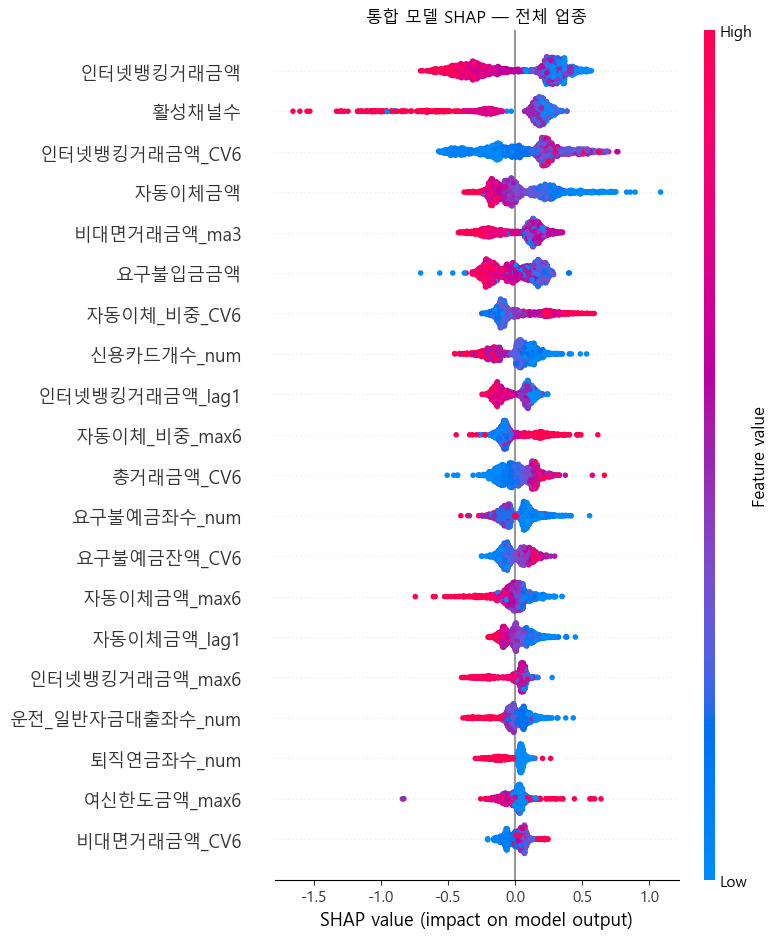

In [40]:
# ============================================================
# SHAP / Feature Importance
# ============================================================

# 업종별 Feature Importance Top 20은 SHAP 설치 여부와 무관하게 출력
for ind, info in IND_MODELS.items():
    print(f'\n[{ind}] Feature Importance Top 20')
    display(info['feature_importance'].head(20))

# 통합 모델 SHAP은 shap 패키지가 있을 때만 실행
try:
    import shap

    prep = INT_PIPE.named_steps['prep']
    lgbm = INT_PIPE.named_steps['model']

    sample_n = min(1500, len(df_test))
    Xte_raw = df_test.sample(sample_n, random_state=RANDOM_STATE).copy()

    Xte_int = preprocess_for_model(
        Xte_raw,
        num_cols=list(INT_kept),
        cat_cols=list(INT_cat),
        bounds=INT_bounds,
        logset=INT_logset
    )[list(INT_kept) + list(INT_cat)]

    Xt_transformed = prep.transform(Xte_int)
    if hasattr(Xt_transformed, 'toarray'):
        Xt = Xt_transformed.toarray()
    else:
        Xt = np.asarray(Xt_transformed)

    ohe = prep.named_transformers_.get('cat') if 'cat' in prep.named_transformers_ else None
    feature_names = (list(ohe.get_feature_names_out(INT_cat)) if ohe is not None else []) + list(INT_kept)

    explainer = shap.TreeExplainer(lgbm)
    shap_values = explainer.shap_values(Xt)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    shap.summary_plot(
        shap_values,
        Xt,
        feature_names=feature_names,
        show=False,
        max_display=20
    )
    plt.title('통합 모델 SHAP — 전체 업종')
    plt.tight_layout()
    plt.show()

    SHAP_INT = {
        'shap': shap_values,
        'X': Xt,
        'names': feature_names
    }

except Exception as e:
    print('SHAP 계산 스킵:', e)
    SHAP_INT = None

## 단계5 — 중요 변수 기반 EDA (y=0 vs y=1, df_model 기준 원본단위)

In [41]:
# 업종별 상위 중요 수치형 변수에 대해 y=0/1 비교 (clip/log 전 원본 dfx 기준)
EDA_ROWS = []

for ind, info in IND_MODELS.items():
    sub = dfx[dfx['업종_대분류'] == ind]

    # FI 상위 중 수치형 원본 변수만(one-hot 더미 제외), 누수 피처 제외
    top_num = [
        f for f in info['feature_importance']['feature']
        if f in NUM_FEAT_ALL and not is_forbidden_feature(f)
    ][:8]

    print(f'\n[{ind}] 주요 수치형 변수 y=0 vs y=1')

    for f in top_num:
        g0 = sub.loc[sub['y'] == 0, f]
        g1 = sub.loc[sub['y'] == 1, f]

        row = {
            '업종': ind,
            '변수': f,
            'y0_평균': round(g0.mean(), 2),
            'y1_평균': round(g1.mean(), 2),
            'y0_중앙': round(g0.median(), 2),
            'y1_중앙': round(g1.median(), 2),
            '차이': round(g1.mean() - g0.mean(), 2),
            '차이율': round((g1.mean() - g0.mean()) / (abs(g0.mean()) + 1e-9), 3)
        }
        EDA_ROWS.append(row)

    print(pd.DataFrame([r for r in EDA_ROWS if r['업종'] == ind]).to_string(index=False))

# high-zero categorical 변수의 y=1 비율 차이
print('\n[high-zero zero_cat 변수의 y=1 비율 (nonzero일 때)]')
for c in [c for c in high_zero_cat_cols if c in CAT_FEAT_ALL][:10]:
    nz = dfx[dfx[c] == 'nonzero']
    if len(nz) > 0:
        print(f'  {c}: nonzero일 때 y=1 비율 {nz["y"].mean()*100:.1f}% (전체 {dfx["y"].mean()*100:.1f}%)')


[제조업] 주요 수치형 변수 y=0 vs y=1
 업종            변수  y0_평균  y1_평균  y0_중앙  y1_중앙      차이    차이율
제조업   자동이체금액_max6 300.30 101.88  37.00  11.00 -198.42 -0.661
제조업  자동이체_비중_max6   0.32   0.59   0.23   0.61    0.27  0.823
제조업     총거래금액_CV6   0.35   0.59   0.27   0.45    0.24  0.703
제조업        자동이체금액 244.20  76.58  30.00   8.20 -167.62 -0.686
제조업   요구불예금잔액_ma3 211.18  81.62  40.80   5.49 -129.56 -0.614
제조업 인터넷뱅킹거래금액_CV6   0.42   0.73   0.31   0.51    0.30  0.717
제조업    자동이체금액_CV6   0.22   0.30   0.15   0.20    0.08  0.363
제조업   자동이체_비중_CV6   0.34   0.46   0.30   0.42    0.12  0.356

[도매 및 소매업] 주요 수치형 변수 y=0 vs y=1
      업종            변수  y0_평균  y1_평균  y0_중앙  y1_중앙      차이    차이율
도매 및 소매업 인터넷뱅킹거래금액_CV6   0.33   0.66   0.23   0.43    0.33  1.013
도매 및 소매업        자동이체금액 274.71  21.24  23.00   5.10 -253.47 -0.923
도매 및 소매업    자동이체금액_CV6   0.22   0.30   0.15   0.22    0.09  0.392
도매 및 소매업   자동이체금액_max6 299.03  33.56  27.00   7.00 -265.47 -0.888
도매 및 소매업   자동이체_비중_CV6   0.30   0.46   0.26   0.40    0.15  

## 5-3. 출력물 정리

In [42]:
# ============================================================
# 출력물 정리
# ============================================================

print('=' * 70)
print('15-1. 데이터 요약')
print('=' * 70)
print('NOTEBOOK_NAME       :', NOTEBOOK_NAME)
print('전체 df shape       :', df.shape)
print('df_model shape      :', df_model.shape)
print('법인ID 수           :', df_model['법인ID'].nunique())
print('기간                :', df['기준년월'].min(), '~', df['기준년월'].max())
print('warm-up 행 수       :', (~df['y_available']).sum())
print('y 분포              :', dict(df_model['y'].value_counts()))

print('\n업종별 행 수')
display(dfx['업종_대분류'].value_counts().to_frame('row_count'))

print('\n업종별 법인 수')
display(dfx.groupby('업종_대분류')['법인ID'].nunique().sort_values(ascending=False).to_frame('corp_count'))

print('\n' + '=' * 70)
print('15-2. 0비율 처리 요약')
print('=' * 70)
print('100% 0 제거 변수 수        :', len(zero_100_cols))
print('0비율 85%↑ zero_cat 변수 수:', len(HIGH_ZERO_NUMERIC_DROP_COLS))
print('zero_cat 컬럼              :', high_zero_cat_cols[:50])
print('high-zero 원본 제거 컬럼    :', HIGH_ZERO_NUMERIC_DROP_COLS[:50])

print('\n' + '=' * 70)
print('15-3. 업종별 모델 성능')
print('=' * 70)
display(res_ind)

print('\n' + '=' * 70)
print('15-4. 통합/앙상블 성능')
print('=' * 70)
display(res_ens)

print('\n' + '=' * 70)
print('15-5. 업종별 Top Feature')
print('=' * 70)
for ind, info in IND_MODELS.items():
    print(f'\n[{ind}]')
    display(info['feature_importance'].head(10))

print('\n' + '=' * 70)
print('15-6. EDA 요약')
print('=' * 70)

if EDA_ROWS:
    eda_df = pd.DataFrame(EDA_ROWS).reindex(columns=[
        '업종', '변수',
        'y0_평균', 'y1_평균',
        'y0_중앙', 'y1_중앙',
        '차이', '차이율'
    ])
    display(eda_df)
else:
    eda_df = pd.DataFrame()
    print('EDA_ROWS가 비어 있습니다.')

# 결과 저장
res_ind_path = f'{NOTEBOOK_NAME}_업종별성능.csv'
res_ens_path = f'{NOTEBOOK_NAME}_앙상블성능.csv'
eda_path = f'{NOTEBOOK_NAME}_eda요약.csv'

res_ind.to_csv(res_ind_path, index=False, encoding='utf-8-sig')
res_ens.to_csv(res_ens_path, index=False, encoding='utf-8-sig')
eda_df.to_csv(eda_path, index=False, encoding='utf-8-sig')

print('\n저장 완료:')
print(' -', res_ind_path)
print(' -', res_ens_path)
print(' -', eda_path)

15-1. 데이터 요약
NOTEBOOK_NAME       : final8
전체 df shape       : (121392, 107)
df_model shape      : (97788, 108)
법인ID 수           : 3372
기간                : 202301 ~ 202512
warm-up 행 수       : 20232
y 분포              : {0: 58131, 1: 39657}

업종별 행 수


,row_count
업종_대분류,
제조업,31697
도매 및 소매업,20474
건설업,16907
부동산업,7801



업종별 법인 수


,corp_count
업종_대분류,
제조업,1093
도매 및 소매업,706
건설업,583
부동산업,269



15-2. 0비율 처리 요약
100% 0 제거 변수 수        : 4
0비율 85%↑ zero_cat 변수 수: 94
zero_cat 컬럼              : ['거치식예금잔액_감소여부_zero_cat', '적립식예금잔액_감소여부_zero_cat', '운전_당좌대출잔액_zero_cat', '여신한도금액_감소여부_zero_cat', '수출_감소여부_zero_cat', '운전_외상매출채권담보대출잔액_zero_cat', '운전_무역금융잔액_zero_cat', '운전_외상매출채권담보대출좌수_num_zero_cat', '체크카드비율_증가_zero_cat', '수출_비중_zero_cat', '외환_수출실적금액_zero_cat', '운전_무역금융좌수_num_zero_cat', '수익증권잔액_zero_cat', '운전_당좌대출좌수_num_zero_cat', '시설_에너지절약시설대출잔액_zero_cat', '총외환실적_감소여부_zero_cat', '시설_에너지절약시설대출좌수_num_zero_cat', '여신_시설자금대출잔액_감소여부_zero_cat', '외환_수입실적금액_zero_cat', '운전_할인어음잔액_zero_cat', '수익증권좌수_num_zero_cat', '거치식예금잔액_CV6_zero_cat', '체크카드사용금액_zero_cat', '체크카드_비율_zero_cat', '수출입_불균형_zero_cat', '총외환실적_zero_cat', '외환거래여부_zero_cat', '외환_비중_zero_cat', '체크카드사용금액_CV6_zero_cat', '체크카드사용금액_ma3_zero_cat', '체크카드사용금액_ma6_zero_cat', '운전_기업구매자금대출잔액_zero_cat', '거치식예금잔액_diff1_zero_cat', '운전_할인어음좌수_num_zero_cat', '지역_결측_여부_zero_cat', 'region_unknown_flag_zero_cat', '운전_기업구매자금대출좌수_num_zero_cat', '여신한도금액_diff1_zero

...


[부동산업]


,feature,importance
363,요구불예금잔액_ma6,272
357,자동이체_비중_max6,232
208,총여신잔액,220
229,총거래금액_CV6,215
227,총거래금액_ma6,211
199,자동이체금액,202
364,요구불예금잔액_CV6,195
319,비대면_비중_max6,193
195,여신_운전자금대출잔액,186
264,자동이체금액_CV6,184



15-6. EDA 요약


,업종,변수,y0_평균,y1_평균,y0_중앙,y1_중앙,차이,차이율
0,제조업,자동이체금액_max6,300.30,101.88,37.00,11.00,-198.42,-0.661
1,제조업,자동이체_비중_max6,0.32,0.59,0.23,0.61,0.27,0.823
2,제조업,총거래금액_CV6,0.35,0.59,0.27,0.45,0.24,0.703
3,제조업,자동이체금액,244.20,76.58,30.00,8.20,-167.62,-0.686
4,제조업,요구불예금잔액_ma3,211.18,81.62,40.80,5.49,-129.56,-0.614
5,제조업,인터넷뱅킹거래금액_CV6,0.42,0.73,0.31,0.51,0.30,0.717
6,제조업,자동이체금액_CV6,0.22,0.30,0.15,0.20,0.08,0.363
7,제조업,자동이체_비중_CV6,0.34,0.46,0.30,0.42,0.12,0.356
8,도매 및 소매업,인터넷뱅킹거래금액_CV6,0.33,0.66,0.23,0.43,0.33,1.013
9,도매 및 소매업,자동이체금액,274.71,21.24,23.00,5.10,-253.47,-0.923



저장 완료:
 - final8_업종별성능.csv
 - final8_앙상블성능.csv
 - final8_eda요약.csv
